In [3]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
# Add the head direcoty to sys.path
workspace_root = os.getcwd()  
sys.path.insert(0, workspace_root + "/../../../../")


# import this repo's classes
from pyanalib.split_df_helpers import *
import pyanalib.pandas_helpers as ph
from makedf.util import *
sys.path.insert(0, workspace_root + "/../../")
import loaddf
from pot import *
from plot_tools import *
import gump_cuts as gc
import kinematics
from tqdm.auto import tqdm
import importlib
importlib.reload(loaddf)
importlib.reload(gc)

<module 'gump_cuts' from '/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py'>

In [4]:
OUTDIR='/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/EventSelectionPlots/Apr18'

In [5]:
class PlotObj:
  def __init__(self, title, label):
    self.title = title
    self.label = label

# Colors for plots
FONTSIZE = 14
plt.style.use('/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/dune.mplstyle')

In [6]:
mode_list = [1, 10, 0]

mode_labels = ["Cosmic", "Dirt", 'Other $\\nu$', '$\\nu_\\mu$ CC RES', '$\\nu_\\mu$ CC MEC', '$\\nu_\\mu$ CC QE']
HAWKS_COLORS = ["#95af8b", "#43140b", "#c89648", "#1e3f54", "#d54c28", "#315031"]

def nuFV(df):
    det = df.detector.iloc[0].split(" ")[0]

    vtx = pd.DataFrame({
        "Run": df.Run,
        "x": df.true_vtx_x,
        "y": df.true_vtx_y,
        "z": df.true_vtx_z,
    })
    return ~np.isnan(df.true_vtx_x) & gc._fv_cut(vtx, det, 0, 0, 0, 0)

def breakdown_mode(var, df):
    """Break down variable by interaction mode."""
    numu_cc = (np.abs(df.true_nu_pdg) == 14) & (df.true_isnc == False)
    fid = nuFV(df)
    fid = ~df.dirt

    ret = [
        var[np.isnan(df.genie_mode)],
        var[~fid & ~np.isnan(df.genie_mode)],
        var[(~np.any([df.genie_mode == i for i in mode_list], axis=0) | ~numu_cc) & fid & ~np.isnan(df.genie_mode)]
    ] +\
        [var[(df.genie_mode == i) & numu_cc & fid] for i in mode_list]
        
    return ret

In [7]:
def make_all_plots(df_nd, df_fd, cut_stage, mode_labels, det_labels):
    sbnd_title = f"{cut_stage}"
    icarus_title = f"{cut_stage}"

    sbnd_file_top = f"topE_{cut_stage.lower().replace(' ', '_')}_sbnd.png"
    icarus_file_top = f"topE_{cut_stage.lower().replace(' ', '_')}_icarus.png"
    
    sbnd_comp = plot_mode(df_nd, 'nu_E_calo', sbnd_title, sbnd_file_top, r"$E_{reco}$ [GeV]", mode_labels, det_labels[0], eff_bool=False)
    icarus_comp = plot_mode(df_fd, 'nu_E_calo', icarus_title, icarus_file_top, r"$E_{reco}$ [GeV]", mode_labels, det_labels[1], eff_bool=False)
    sbnd_comp = plot_mode(df_nd, 'del_p', sbnd_title, sbnd_file_top, r"$\delta p$ [GeV]", mode_labels, det_labels[0], eff_bool=False)
    icarus_comp = plot_mode(df_fd, 'del_p', icarus_title, icarus_file_top, r"$\delta p$ [GeV]", mode_labels, det_labels[1], eff_bool=False)
    return sbnd_comp, icarus_comp

def plot_mode(df, var, title, outfile, label, mode_labels, det, eff_bool=False):
    b = np.linspace(0,2.5,21)
    if var == 'nu_E_calo':
        b = np.array([0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.25, 1.5])
    var_data = df[var]
    og_sig_ct = df['og_sig_ct'].to_numpy()[0]

    tvar = breakdown_mode(var_data, df)
    glob_scale = breakdown_mode(df['glob_scale'], df)
    # Do purity/efficiency calculation
    ret = [len(t) for t in tvar]
    sig_ct = ret[0]
    tot_ct = sum(ret)
    eff = sig_ct/og_sig_ct
    pur = sig_ct/tot_ct

    fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))
    plt.xlabel(label)
    
    if det == "SBND":
        plt.ylabel(r'Events / 50 MeV / $10^{20}$ POT')
    elif det == "ICARUS":
        plt.ylabel(r'Events / 50 MeV / $5\times 10^{20}$ POT')

    bin_widths = b[1:] - b[:-1]

    n = []
    
    for t, g in zip(tvar, glob_scale):
        n_unscaled, _ = np.histogram(t, bins=b, weights=g)
        n.append(n_unscaled)

    n, bins, _ = plt.hist([bin_centers(b) for _ in n], bins=b, weights=[ni/(bin_widths*20) for ni in n], 
                         stacked=True, label=mode_labels, color=HAWKS_COLORS)
    
    #n, bins, _ = plt.hist(tvar, bins=b, stacked=True, label=mode_labels,
    #                    color=HAWKS_COLORS, weights=[g for g in glob_scale])
    
    plt.title(f"$\\bf{{{det}}}$  {title}")
    plt.legend()

    if eff_bool:
        ax.text(0.6, 0.33, f"Composition {{:.2f}}%".format(100*pur),
                transform=ax.transAxes, fontsize=FONTSIZE)
        ax.text(0.6, 0.4, f"Efficiency {{:.2f}}%".format(100*eff),
                transform=ax.transAxes, fontsize=FONTSIZE)
    plt.tight_layout()
    plt.savefig(det+var+title.strip()+'.png')
    plt.show()
    plt.clf()
    return ret/np.sum(ret)

def plot_PID_cut(var, cut_vals, title, outfile, xlims=[0, 100],
                 labels=['SBND', 'ICARUS'], arrow_dir='None', arrow_txt='None'):

    var_nd, var_fd = var
    cut_val_nd, cut_val_fd = cut_vals
    b = np.linspace(xlims[0], xlims[1], 40)


    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 4.5), sharex=True)
    ax1.set_title(title+" Cut")
    plt.subplots_adjust(hspace=0)

    n1, bins, _ = ax1.hist(var_nd[0], bins=b, histtype='step', color=HAWKS_COLORS[0],
                           label=labels[0], stacked=False, weights=[1/len(var_nd[0])]*len(var_nd[0]), linestyle='-')
    n2, bins, _ = ax1.hist(var_nd[1], bins=b, histtype='step', color=HAWKS_COLORS[0],
                           label=labels[1], stacked=False, weights=[1/len(var_nd[1])]*len(var_nd[1]), linestyle='--')
    n3, bins, _ = ax2.hist(var_fd[0], bins=b, histtype='step', color=HAWKS_COLORS[1],
                           label=labels[2], stacked=False, weights=[1/len(var_fd[0])]*len(var_fd[0]), linestyle='-')
    n4, bins, _ = ax2.hist(var_fd[1], bins=b, histtype='step', color=HAWKS_COLORS[1],
                           label=labels[3], stacked=False, weights=[1/len(var_fd[1])]*len(var_fd[1]), linestyle='--')

    for ax in [ax1, ax2]:
        ax.set_ylabel('Events')
    ax2.set_xlabel(title)
    ax1.legend()
    ax2.legend()

    max_1 = np.max([n1, n2])*1.2
    max_2 = np.max([n3, n4])*1.2
    ax1.vlines(cut_val_nd, 0, max_1, colors='black', linestyle='--')
    ax2.vlines(cut_val_fd, 0, max_2, colors='black', linestyle='--')
    ax1.set_ylim(0, max_1)
    ax2.set_ylim(0, max_2)
    
    if arrow_dir == 'right':
       ax1.arrow(cut_val_nd, max_1/2, (xlims[1]-xlims[0])/8, 0, head_width=0.1*max_1,
                 head_length=(xlims[1]-xlims[0])/40, fc='red', ec='red')
       ax2.arrow(cut_val_fd, max_2/2, (xlims[1]-xlims[0])/8, 0, head_width=0.1*max_2,
                 head_length=(xlims[1]-xlims[0])/40, fc='red', ec='red')
       ax1.text(cut_val_nd+10, 0.35*max_1, arrow_txt, color='red')
       ax2.text(cut_val_fd+10, 0.35*max_2, arrow_txt, color='red')
    elif arrow_dir == 'left':
       ax1.arrow(cut_val_nd, max_1/2, -(xlims[1]-xlims[0])/8, 0, head_width=0.1*max_1,
                 head_length=(xlims[1]-xlims[0])/40, fc='red', ec='red')
       ax2.arrow(cut_val_fd, max_2/2, -(xlims[1]-xlims[0])/8, 0, head_width=0.1*max_2,
                 head_length=(xlims[1]-xlims[0])/40, fc='red', ec='red')
       ax1.text(cut_val_nd-20, 0.8*max_1, arrow_txt, color='red')
       ax2.text(cut_val_fd-20, 0.8*max_2, arrow_txt, color='red')

    plt.tight_layout()
    plt.savefig(title.strip()+'.png')
    plt.show()
    plt.clf()

def plot_nuscore_cut(var_nd, cut_vals_nd, var_fd, cut_vals_fd, title, outfile, xlims=[0, 100],
                     labels=['SBND', 'ICARUS'], arrow_dir='None', arrow_txt='None'):

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 4.5), sharex=True)
    plt.subplots_adjust(hspace=0)

    b = np.linspace(xlims[0], xlims[1], 40)
    n1, bins, _ = ax1.hist(var_nd[0], bins=b, histtype='step', color=HAWKS_COLORS[0],
                           label=labels[0], stacked=False, weights=[1/len(var_nd[0])]*len(var_nd[0]), linestyle='-')
    n2, bins, _ = ax1.hist(var_nd[1], bins=b, histtype='step', color=HAWKS_COLORS[0],
                           label=labels[1], stacked=False, weights=[1/len(var_nd[1])]*len(var_nd[1]), linestyle='--')
    n3, bins, _ = ax2.hist(var_fd[0], bins=b, histtype='step', color=HAWKS_COLORS[1],
                           label=labels[2], stacked=False, weights=[1/len(var_fd[0])]*len(var_fd[0]), linestyle='-')

    n4, bins, _ = ax2.hist(var_fd[1], bins=b, histtype='step', color=HAWKS_COLORS[1],
                           label=labels[3], stacked=False, weights=[1/len(var_fd[1])]*len(var_fd[1]), linestyle='--')

    # Style
    for ax in [ax1, ax2]:
        ax.tick_params(axis='both', which='both', direction='in', length=6, width=1.5,  top=True, right=True)
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
        ax.set_ylabel('Events')
    ax2.set_xlabel('Nu Score')
    ax1.legend()
    ax2.legend()

    max_1 = np.max([n1, n2])*3.5
    max_2 = np.max(n4)*3.5
    ax1.vlines(cut_vals_nd, 0, max_1, colors='black', linestyle='--')
    ax2.vlines(cut_vals_fd, 0, max_2, colors='black', linestyle='--')
    ax1.set_ylim(0, max_1)
    ax2.set_ylim(0, max_2)

    ax1.arrow(cut_vals_nd[0], max_1/2, (xlims[1]-xlims[0])/8, 0, head_width=0.1*max_1,
              head_length=(xlims[1]-xlims[0])/40, fc='red', ec='red')
    ax2.arrow(cut_vals_fd[0], max_2/2, (xlims[1]-xlims[0])/8, 0, head_width=0.1*max_2,
              head_length=(xlims[1]-xlims[0])/40, fc='red', ec='red')
    ax1.text(cut_vals_nd[0]+(xlims[1]-xlims[0])/20, 0.35*max_1, arrow_txt, color='red')
    ax2.text(cut_vals_fd[0]+(xlims[1]-xlims[0])/20, 0.35*max_2, arrow_txt, color='red')

    plt.tight_layout()
    plt.savefig(title.strip()+'.png')
    plt.show()
    plt.clf()

def plot_composition(percentages, time_labels=None, components=None, title='', outfile='comp.png'):
    percentages = np.flip(np.array(percentages), axis=0)
    num_time_points, num_components = percentages.shape

    y = np.arange(num_time_points)

    left = np.zeros(num_time_points)
    for i in range(num_components):
        plt.barh(y, percentages[:, i], left=left, label=components[i])
        left += percentages[:, i]

    plt.yticks(y, labels=reversed(time_labels))
    plt.tick_params(axis='both', which='both', direction='in', length=6, width=1.5, top=True, right=True)
    plt.xlabel('Percentage')
    plt.xlim(0, 1)
    plt.legend(frameon=True)
    plt.title('Composition, '+title)
    plt.tight_layout()
    plt.savefig(title.strip()+'.png')
    plt.show()
    plt.clf()

In [8]:
def FV(df, det):    
    is_spine = "SPINE" in RECO
    
    ret = gc.slcfv_cut(df, det) & gc.mufv_cut(df, det) & gc.pfv_cut(df, det) 
    
    if is_spine:
        ret = ret & (df.is_time_contained)
    
    return ret

def FVSBND(df):
    return FV(df, "SBND")

def FVICARUS(df):
    return FV(df, "ICARUS")



def TrueAV(df, det):
    vtx = pd.DataFrame({'x': df.true_vtx_x,
                       'y': df.true_vtx_y,
                       'z': df.true_vtx_z}, index=df.index)
    return gc._fv_cut(vtx, det, 0, 0, 0, 0)

def TrueAVSBND(df):
    return TrueAV(df, "SBND")

def TrueAVICARUS(df):
    return TrueAV(df, "ICARUS")

def OOAVSBND(df):
    return ~np.isnan(df.true_vtx_x) & ~TrueAVSBND(df)

def OOAVICARUS(df):
    return ~np.isnan(df.true_vtx_x) & ~TrueAVICARUS(df)

def ICARUS_dirtcut(df):
    # mbox from CV sample
    xlo = -378.49
    ylo = -191.86
    zlo = -904.950652270838

    xhi = 378.49
    yhi = 144.96
    zhi = 904.950652270838
    vtx = pd.DataFrame({'x': df.true_vtx_x,
                       'y': df.true_vtx_y,
                       'z': df.true_vtx_z}, index=df.index)

    return ~((vtx.x > xlo) & (vtx.x < xhi) & (vtx.y > ylo) & (vtx.y < yhi) & (vtx.z > zlo) & (vtx.z < zhi))



In [9]:
IGOAL_POT = 5e20
SGOAL_POT = 1e20
RECO = "PANDORA"

DF_DIR = "/exp/sbnd/data/users/nrowe/GUMP/sbn-rewgted-6/"

RUN2_MC_FILES = [DF_DIR + "ICARUSRun2_SpringMCOverlay_rewgt.df"]
RUN4_MC_FILES = [DF_DIR + "ICARUSRun4_SpringMCOverlay_rewgt_%i.df" % i for i in range(10)]
RUN2_BEAMOFF_FILE = DF_DIR + "ICARUS_SpringRun2BNBOff_unblind_prescaled.df"
RUN4_BEAMOFF_FILES = [DF_DIR + "ICARUSRun2_BNBoff_uncalo_unblind_%i.df" % i for i in range(10)]
RUN2_DIRT_FILES = [DF_DIR + "ICARUSRun2_SpringMCDirt.df"]
RUN4_DIRT_FILES = [DF_DIR + "ICARUSRun4_SpringMCDirt.df"]
RUN2_POT = 2e20
RUN4_POT = 3e20

MC_FILES = [DF_DIR + "SBND_SpringMC_rewgt_5_%i.df" % i for i in range(10)]
BEAMOFF_FILE = DF_DIR + "SBND_SpringBNBOffData_5000.df"
DIRT_FILE = "/exp/sbnd/data/users/gputnam/GUMP/sbn-rewgted-6/SBND_SpringLowEMC.df"

In [10]:
def FV(df, det):    
    is_spine = "SPINE" in RECO
    
    ret = gc.slcfv_cut(df, det) & gc.mufv_cut(df, det) & gc.pfv_cut(df, det) 
    
    if is_spine:
        ret = ret & (df.is_time_contained)
    
    return ret

def FVSBND(df):
    return FV(df, "SBND") & gc.flash_cut(df, "SBND")

def FVICARUSRun2(df):
    return FV(df, "ICARUS Run2") & gc.flash_cut(df, "ICARUS Run2")

def FVICARUSRun4(df):
    return FV(df, "ICARUS Run4") & gc.flash_cut(df, "ICARUS Run4")

In [11]:
df_r2, _, POT_r2 = loaddf.loadl(RUN2_MC_FILES, include_syst=True, reweight_aFF=True, preselection=FVICARUSRun2, detector="ICARUS Run2")
df_r4, _, POT_r4 = loaddf.loadl(RUN4_MC_FILES, include_syst=True, reweight_aFF=True, preselection=FVICARUSRun4, detector="ICARUS Run2")
df_r4['detector'] = "ICARUS Run4"
# Scale each run to its target POT before combining
loaddf.scale_pot(df_r2, POT_r2, RUN2_POT)
loaddf.scale_pot(df_r4, POT_r4, RUN4_POT)
Idf = pd.concat([df_r2, df_r4]).reset_index(drop=True)
Idf['is_offbeam_sample'] = False
Idf['is_dirt_sample'] = False
Ipot = RUN2_POT + RUN4_POT

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [12]:
Sdf, Smatch, Spot = loaddf.loadl(MC_FILES, include_syst=True, reweight_aFF=True, preselection=FVSBND, detector="SBND")
Sdf['is_offbeam_sample'] = False
Sdf['is_dirt_sample'] = False

  0%|          | 0/10 [00:00<?, ?it/s]

In [13]:
offbeam_r2, _, offbeampot_r2 = loaddf.load(RUN2_BEAMOFF_FILE, include_syst=False, load_truth=False, 
                                  preselection=FVICARUSRun2, offbeampot=True, detector="ICARUS Run2")
offbeam_r4, _, offbeampot_r4 = loaddf.loadl(RUN4_BEAMOFF_FILES, include_syst=False, load_truth=False, 
                                  preselection=FVICARUSRun4, offbeampot=True, detector="ICARUS Run4", match_Enu=False)
loaddf.scale_pot(offbeam_r2, offbeampot_r2, RUN2_POT)
loaddf.scale_pot(offbeam_r4, offbeampot_r4, RUN4_POT)
Ioffbeam = pd.concat([offbeam_r2, offbeam_r4]).reset_index(drop=True)
Ioffbeam['is_offbeam_sample'] = True
Ioffbeam['is_dirt_sample'] = False
Ioffbeampot = RUN2_POT + RUN4_POT

  0%|          | 0/10 [00:00<?, ?it/s]

In [14]:
Soffbeam, Soffbeammatch, Soffbeampot = loaddf.load(BEAMOFF_FILE, include_syst=False, load_truth=False, 
                                      preselection=FVSBND, offbeampot=True, detector="SBND")
Soffbeam['is_offbeam_sample'] = True
Soffbeam['is_dirt_sample'] = False

In [15]:
dirt_r2, _, dirtpot_r2 = loaddf.loadl(RUN2_DIRT_FILES, njob=min(len(RUN2_DIRT_FILES), 10), preselection=FVICARUS, include_syst=False, detector="ICARUS Run2")
dirt_r4, _, dirtpot_r4 = loaddf.loadl(RUN4_DIRT_FILES, njob=min(len(RUN4_DIRT_FILES), 10), preselection=FVICARUS, include_syst=False, detector="ICARUS Run4")
Sdirt, _, Sdirtpot = loaddf.load(DIRT_FILE, preselection=FVSBND, include_syst=False, detector="SBND")
Sdirt['is_offbeam_sample'] = False
Sdirt['is_dirt_sample'] = True

loaddf.scale_pot(dirt_r2, dirtpot_r2, RUN2_POT)
loaddf.scale_pot(dirt_r4, dirtpot_r4, RUN4_POT)
Idirt = pd.concat([dirt_r2, dirt_r4]).reset_index(drop=True)
Idirt['is_offbeam_sample'] = False
Idirt['is_dirt_sample'] = True
Idirtpot = RUN2_POT + RUN4_POT

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

In [16]:
import warnings
from pandas.errors import PerformanceWarning

warnings.filterwarnings('ignore', category=PerformanceWarning)

Idirt = Idirt[ICARUS_dirtcut(Idirt)].copy()

if "dirt" not in Sdf.columns:
    Sdf["dirt"] = False
    Sdirt["dirt"] = True

if "dirt" not in Idf.columns:
    Idf["dirt"] = False
    Idirt["dirt"] = True

loaddf.scale_pot(Sdf, Spot, SGOAL_POT)
loaddf.scale_pot(Sdirt, Sdirtpot, SGOAL_POT)
loaddf.scale_pot(Soffbeam, Soffbeampot, SGOAL_POT)

#loaddf.scale_pot(Idf, Ipot, IGOAL_POT)
#loaddf.scale_pot(Idirt, Idirtpot, IGOAL_POT)
#loaddf.scale_pot(Ioffbeam, Ioffbeampot, IGOAL_POT)

ICARUS_OOT_COSMIC_SCALE = 0.5949386190547118
SBND_OOT_COSMIC_SCALE = 0.9961317495469143

Idf.loc[Idf.is_cosmic, "glob_scale"] *= ICARUS_OOT_COSMIC_SCALE
Idirt.loc[Idirt.is_cosmic, "glob_scale"] *= ICARUS_OOT_COSMIC_SCALE

Sdf.loc[Sdf.is_cosmic, "glob_scale"] *= SBND_OOT_COSMIC_SCALE
Sdirt.loc[Sdirt.is_cosmic, "glob_scale"] *= SBND_OOT_COSMIC_SCALE

Sdf = pd.concat([Sdf[~Sdf.dirt], Sdirt])
Idf = pd.concat([Idf[~Idf.dirt], Idirt])
#Sdf = pd.concat([Sdf[~Sdf.dirt], Sdirt, Soffbeam])
#Idf = pd.concat([Idf[~Idf.dirt], Idirt, Ioffbeam])

In [17]:
df_nd = Sdf.copy()
df_fd = Idf.copy()

#df_nd['glob_scale'] = 1e20/Spot
#df_fd['glob_scale'] = 5e20/Ipot

In [18]:
df_nd['is_sig'] = (df_nd.true_isnc == 0) & (df_nd.is_contained) & (df_nd.mu_true_pdg == 13) & (df_nd.p_true_pdg == 2212) & (df_nd.true_nu_pdg == 14) & np.isnan(df_nd.other_shw_length) & np.isnan(df_nd.other_trk_length)
df_fd['is_sig'] = (df_fd.true_isnc == 0) & (df_fd.is_contained) & (df_fd.mu_true_pdg == 13) & (df_fd.p_true_pdg == 2212) & (df_fd.true_nu_pdg == 14) & np.isnan(df_fd.other_shw_length) & np.isnan(df_fd.other_trk_length)

df_nd['is_other_numucc'] = (df_nd.true_isnc == 0) & (df_nd.is_contained) & ((df_nd.mu_true_pdg != 13) | (df_nd.p_true_pdg != 2212)) & (df_nd.true_nu_pdg == 14)
df_fd['is_other_numucc'] = (df_fd.true_isnc == 0) & (df_fd.is_contained) & ((df_fd.mu_true_pdg != 13) | (df_fd.p_true_pdg != 2212)) & (df_fd.true_nu_pdg == 14)

df_nd['is_nc'] = df_nd.true_isnc
df_fd['is_nc'] = df_fd.true_isnc

df_nd['is_fv'] = df_nd.is_contained
df_fd['is_fv'] = df_fd.is_contained

comp_sbnd = []
comp_icarus = []
cut_labels = ["Preselection", "NuScore Cut", "Two Prong", "PID"]
det_labels = ("SBND", "ICARUS")

df_nd['og_sig_ct'] = len(df_nd.is_sig[df_nd.is_sig == True])
df_fd['og_sig_ct'] = len(df_fd.is_sig[df_fd.is_sig == True])

In [19]:
# FV Cut
importlib.reload(gc)
df_nd = gc.all_cuts(df_nd, "SBND")
df_fd = gc.all_cuts(df_fd, "ICARUS")

/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:126: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[True True True ... True True True]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:126: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[True True True ... True True True]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:126: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[True True True ..

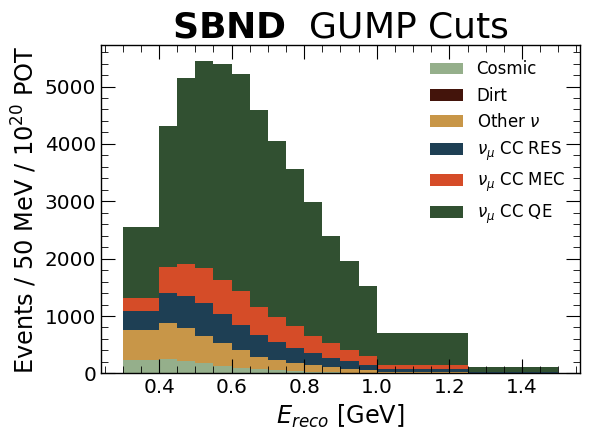

/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:126: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[True True True ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:126: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[True True True ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]


<Figure size 640x480 with 0 Axes>

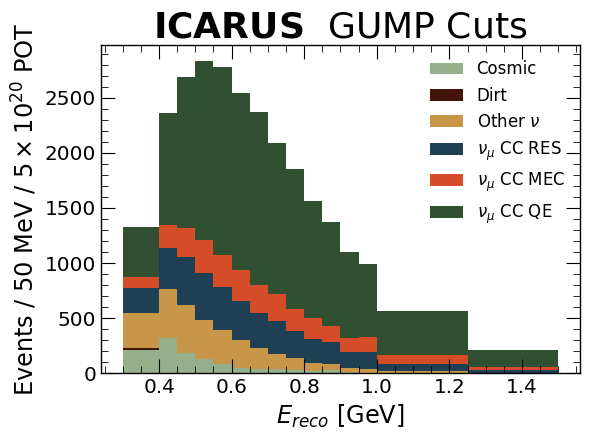

<Figure size 640x480 with 0 Axes>

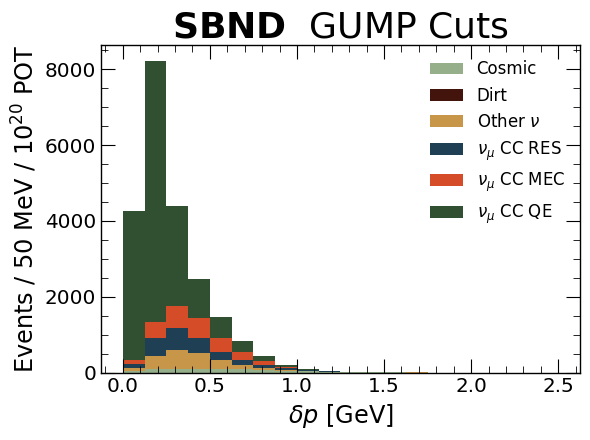

/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:126: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[True True True ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../gump_cuts.py:126: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[True True True ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  ret[df.Run == 4] = FVRun4[df.Run == 4]


<Figure size 640x480 with 0 Axes>

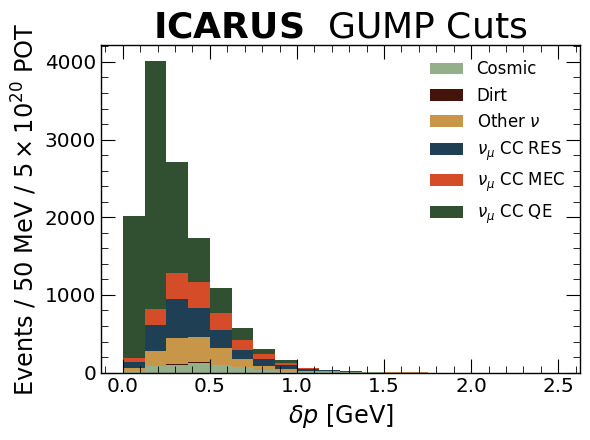

(array([0.03132912, 0.        , 0.08847415, 0.09988794, 0.11497489,
        0.66533391]),
 array([4.98551628e-02, 3.24747022e-05, 1.07932920e-01, 1.53365029e-01,
        1.17383059e-01, 5.71431355e-01]))

<Figure size 640x480 with 0 Axes>

In [20]:
make_all_plots(df_nd, df_fd, 'GUMP Cuts', mode_labels, ['SBND', 'ICARUS'])

In [84]:
import h5py

def read_dfs(file, key):
    with h5py.File(file, "r") as f:
        keys = [k for k in f.keys() if k.startswith(key)]
        return pd.concat([pd.read_hdf(file, k) for k in keys])

def calc_OFF_w(DETECTOR):
    DF_DIR = "/exp/sbnd/data/users/gputnam/GUMP/sbn-rewgted-6/"
    
    if DETECTOR == "ICARUS Run2":
        ONBEAM = DF_DIR + "ICARUS_SpringRun2BNB_unblind_prescaled.df"
        OFFBEAM = DF_DIR + "ICARUS_SpringRun2BNBOff_unblind_prescaled.df"
    elif DETECTOR == "ICARUS Run4":
        ONBEAM = DF_DIR + "ICARUS_SpringRun4BNB_unblind_prescaled.df"
        OFFBEAM = DF_DIR + "ICARUS_SpringRun4BNBOff_unblind_prescaled.df"
    elif DETECTOR == "SBND": 
        ONBEAM = DF_DIR + "SBND_SpringBNBData_Dev.df"
        OFFBEAM = DF_DIR + "SBND_SpringBNBOffData_5000.df"
    
    if "ICARUS" in DETECTOR:
        ngates_ON = read_dfs(ONBEAM, "trig").gate_delta.sum()*(1-1/100.)
        ngates_OFF = read_dfs(OFFBEAM, "trig").gate_delta.sum()*(1-1/20.)
        
        OFF_w = ngates_ON / ngates_OFF
    elif "SBND" in DETECTOR:
        ngates_ON = read_dfs(ONBEAM, "bnb").shape[0]
        ngates_OFF = read_dfs(OFFBEAM, "hdr").noffbeambnb.sum()
    
        f_factor = 0.0754
        OFF_w = (1. - f_factor) * (ngates_ON) / (ngates_OFF)
    return OFF_w

In [125]:
DF_DIR = "/exp/sbnd/data/users/gputnam/GUMP/sbn-rewgted-6/"

DETECTOR="SBND"

if DETECTOR == "ICARUS Run2":
    ONBEAM = DF_DIR + "ICARUS_SpringRun2BNB_unblind_prescaled.df"
    OFFBEAM = DF_DIR + "ICARUS_SpringRun2BNBOff_unblind_prescaled.df"
    
    ONBEAMPOT = DF_DIR + "ICARUS_SpringRun2BNB_unblind_prescaled_POT.df"

    MC_FILES = [DF_DIR + "ICARUS_SpringMCOverlay_rewgt.df"]
    DIRT_FILE = None
    # DIRT_FILE = DF_DIR + "ICARUS_SpringMCDirt_slimwgt.df"
    
    DETVAR_FILES = []
    DETVAR_NAMES = []
elif DETECTOR == "ICARUS Run4":
    ONBEAM = DF_DIR + "ICARUS_SpringRun4BNB_unblind_prescaled.df"
    OFFBEAM = DF_DIR + "ICARUS_SpringRun4BNBOff_unblind_prescaled.df"
    
    ONBEAMPOT = DF_DIR + "ICARUS_SpringRun4BNB_unblind_prescaled_POT.df"

    MC_FILES = [DF_DIR + "ICARUSRun4_SpringMCOverlay_rewgt_%i.df" % i for i in range(10)]
    DIRT_FILE = None
    # DIRT_FILE = DF_DIR + "ICARUS_SpringMCDirt_slimwgt.df"
    
    DETVAR_FILES = []
    DETVAR_NAMES = []
elif DETECTOR == "SBND": 
    ONBEAM = DF_DIR + "SBND_SpringBNBData_Dev.df"
    OFFBEAM = DF_DIR + "SBND_SpringBNBOffData_5000.df"

    MC_FILES = [DF_DIR + "SBND_SpringMC_rewgt_5_%i.df" % i for i in range(20)]
    DIRT_FILE = DF_DIR + "SBND_SpringLowEMC.df"

    DETVAR_FILES = [
        DF_DIR + "SBND_SpringMC_Nom.df",
        DF_DIR + "SBND_SpringMC_WMXThetaXW.df",
        DF_DIR + "SBND_SpringMC_WMYZ.df",
        # DF_DIR + "SBND_SpringMC_0xSCE.df",
        DF_DIR + "SBND_SpringMC_2xSCE.df",
    ]
    DETVAR_NAMES = ["Nominal",
                    "WM $X\\theta_{xw}$", "WM $YZ$", 
                    # "0x SCE", 
                    "2x SCE"]

/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../../../analysis_village/gump/gump_cuts.py:192: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[out_col] = ang
/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/N8nb/../../../../analysis_village/gump/gump_cuts.py:192: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[out_col] = ang


In [128]:
ONdf,_,_ = loaddf.load(ONBEAM, load_truth=False, include_syst=False, detector=DETECTOR)
ONdf = all_cuts(ONdf, "SBND")
ONdf['keep'] = True
OFFdf,_,_ = loaddf.load(OFFBEAM, load_truth=False, include_syst=False, detector=DETECTOR)
OFFdf = all_cuts(OFFdf, "SBND")
OFFdf['keep'] = True

if len(DETVAR_FILES) > 0:
    if DETECTOR=="SBND":
        detvars, detvars_match, detvar_pots = zip(*[loaddf.load(f, include_syst=False, preselection=FVSBND, detector=DETECTOR) for f in tqdm(DETVAR_FILES)])
        detvars, detvar_pots = loaddf.match_common_evts(detvars_match, detvars, detvar_pots)
else:
    detvars = []
    detvar_pots = []

  0%|          | 0/4 [00:00<?, ?it/s]

In [122]:
def make_plot_data(mcdf, onbeamdf, offbeamdf, POT, var, bins, cut, mc_weight, breakdown, areanorm, breakdown_labels, breakdown_colors, xlabel, title, 
                   det="ICARUS", fillna=np.nan, syst=systematics):
    OFF_w = calc_OFF_w(det)
    
    pvars = breakdown(mcdf.loc[mcdf[cut], var].fillna(fillna), mcdf[mcdf[cut]])
    weights = breakdown(mcdf.loc[mcdf[cut], mc_weight], mcdf[mcdf[cut]])

    NMC_breakdown = []
    for pvar, w in zip(pvars, weights):    
        thisNMC, bins = np.histogram(pvar, bins=bins, weights=w)
        NMC_breakdown.append(thisNMC)
        
    NMC,_ = np.histogram(mcdf.loc[mcdf[cut], var].fillna(fillna), bins=bins, weights=mcdf.loc[mcdf[cut], mc_weight])
    NMC_abs = NMC
    if areanorm:
        diff = (bins[1:] - bins[:-1])
        norm = np.sum(NMC*diff)
        if norm > 1e-5:
            NMC = NMC / norm
            for i in range(len(NMC_breakdown)):
                NMC_breakdown[i] = NMC_breakdown[i] / norm

    NMC_breakdown = np.array(NMC_breakdown)
        
    offbeam_mask = (mcdf['is_offbeam_sample'] == True)
    
    NON,_ = np.histogram(onbeamdf.loc[onbeamdf[cut], var].fillna(fillna), bins=bins)
    NOff,_ = np.histogram(offbeamdf.loc[offbeamdf[cut], var].fillna(fillna), bins=bins)

    N = NON - NOff*OFF_w
    Nerr = np.sqrt(NON + NOff*OFF_w**2)
    if areanorm:
        diff = (bins[1:] - bins[:-1])
        
        norm = np.sum(N*diff)
        if norm > 1e-5:
            N = N / norm
            Nerr = Nerr / norm
    cov = syst.cov(var, cut, bins, NMC_abs, shapeonly=areanorm, fillna=fillna)
    err = np.sqrt(np.diag(cov))

    cov_w_stat = cov + np.diag(Nerr**2) # add stat uncertainty
    chi2, ndof = f_chi2(NMC, N, cov_w_stat)

    return {
        "det": det,
        "title": title,
        "xlabel": xlabel,
        "bins": bins,
        "areanorm": areanorm,
        "breakdown_labels": breakdown_labels,
        "breakdown_colors": breakdown_colors,
        "NMC_breakdown": NMC_breakdown,
        "NMC_total": NMC,
        "NData": N,
        "NDataErr": Nerr,
        "cov": cov,
        "cov_w_stat": cov_w_stat,
        "chi2": chi2,
        "ndof": ndof,
        "POT": POT
    }

In [124]:
def f_chi2(NMC, Ndata, cov):
    # ignore singular entries
    which_bin = NMC > 0

    NMC = NMC[which_bin]
    Ndata = Ndata[which_bin]
    cov = cov[which_bin, :]
    cov = cov[:, which_bin]

    delta = NMC - Ndata
    try:
        cov_inv = np.linalg.inv(cov)
    except np.linalg.LinAlgError as _:
        return -1, which_bin.sum()
        
    return delta@cov_inv@delta, which_bin.sum()

In [ ]:

if len(DETVAR_FILES) > 0:
    detvars, detvars_match, detvar_pots = zip(*[loaddf.load(f, include_syst=False, preselection=FV, detector=DETECTOR) for f in tqdm(DETVAR_FILES)])
    detvars, detvar_pots = loaddf.match_common_evts(detvars_match, detvars, detvar_pots)
else:
    detvars = []
    detvar_pots = []

In [ ]:
# reset df if needed
df_nd = df_nd[~df_nd.dirt]

# add dirt to the CV, and also include it (below) as a 100 syst unc.
df_nd = pd.concat([df_nd, dirt_nd])

# keep copy of non-dirt around for chi2 systematic variation CV
df0_nd = df_nd.loc[~df_nd.dirt, [c for c in df.columns if "univ" not in c]]

# disable systematic weights associated with dirt events
for c in df_nd.columns:
    if "univ" in c:
        df_nd[c] = df_nd[c].fillna(1)
        
# also add it to the detector variations, for consistency
for i in range(len(detvars_nd)):
    detvars[i] = pd.concat([detvars[i], dirt_nd])

chi2_detvars = [[v_chi2hi(df0), v_chi2lo(df0)], v_chi2smear(df0)]

In [118]:
importlib.reload(syst)
importlib.reload(loaddf)

systematics = syst.SystematicList([
    loaddf.FluxSystematic(df_nd),
    loaddf.XSecSystematic(df_nd),
    syst.SystematicList(
        [syst.SampleSystematic(d, cvdf=detvars[0]) for d in detvars[1:]] +
        [syst.SampleSystematic(d, cvdf=df0_nd) for d in chi2_detvars]),
    syst.SystSampleSystematic(df_ooav)
    ])

df_nd['keep'] = True

dat = make_plot_data(df_nd, ONdf, OFFdf, SGOAL_POT, "del_p", np.linspace(0, 0.5, 9), 'keep', "glob_scale", breakdown_mode, True, mode_labels, 
                     HAWKS_COLORS, "$\\delta p$ [GeV]", "MC Data Comparison", det="SBND", syst=systematics, fillna=1.0)

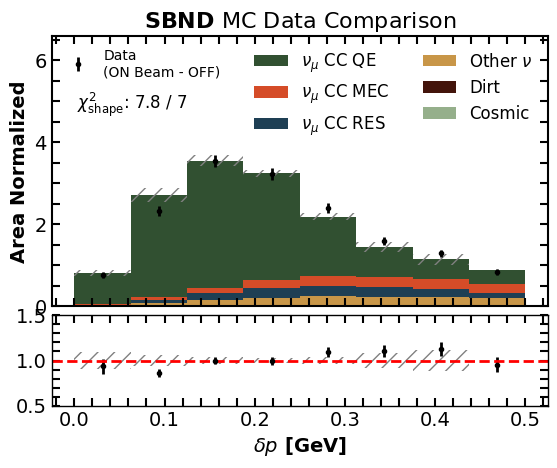

In [119]:
_ = ratio_plot(plt, dat)

In [38]:
def ratio_plot(plt, plotdata):
    fig, (ax0, ax1) = plt.subplots(2, 1, height_ratios=[3, 1], sharex=True)
    bins = plotdata["bins"]
    centers = (bins[:-1] + bins[1:])/2

    NMC_breakdown = plotdata["NMC_breakdown"]
    fill = np.array([centers for _ in range(NMC_breakdown.shape[0])]).T
    ax0.hist(fill, bins=bins, stacked=True, label=plotdata["breakdown_labels"],
                    color=plotdata["breakdown_colors"], weights=NMC_breakdown.T)

    NData = plotdata["NData"]
    NDataErr = plotdata["NDataErr"]
    line = ax0.errorbar(centers, NData, NDataErr, color="black", linestyle="none", marker=".")

    NMC = plotdata["NMC_total"]
    err = np.sqrt(np.diag(plotdata["cov"]))
    ax0.fill_between(bins[:-1], NMC+err, NMC-err, facecolor="none", hatch="//", edgecolor="gray", linewidth=0.0, step="post")

    if "Maximum" in plotdata["xlabel"]:
        ax0.set_yscale("log")

    ax1.errorbar(centers, NData/NMC, NDataErr/NMC, color="black", linestyle="none", marker=".")
    ax1.set_ylim([0.5, 1.5])
    ax1.axhline([1], color="red", linestyle="--")
    ax1.fill_between(bins[:-1], 1+err/NMC, 1-err/NMC, facecolor="none", hatch="//", edgecolor="gray", linewidth=0.0, step="post")

    ax0.tick_params(axis='both', which='both', direction='in', length=6, width=1.5, labelsize=FONTSIZE, top=True, right=True)
    ax1.tick_params(axis='both', which='both', direction='in', length=6, width=1.5, labelsize=FONTSIZE, top=True, right=True)
    for spine in ax0.spines.values():
        spine.set_linewidth(1.5)
    ax1.set_xlabel(plotdata["xlabel"], fontsize=FONTSIZE, fontweight='bold')
    
    if plotdata["areanorm"]:
        ax0.set_ylabel('Area Normalized', fontsize=FONTSIZE, fontweight='bold')
    else:
        ax0.set_ylabel('Events / %.1f$\\times 10^{19}$ POT' % (plotdata["POT"]/1e19), fontsize=FONTSIZE, fontweight='bold')

    det = plotdata["det"]
    title = plotdata["title"]
    ax0.set_title(f"$\\bf{{{det}}}$ {title}", fontsize=FONTSIZE+2)
    ld = ax0.legend([line], ["Data\n(ON Beam - OFF)"], frameon=False, loc="upper left", fontsize=10)

    ax0_l0, ax0_hi = ax0.get_ylim()
    ax0.set_ylim([ax0_l0, ax0_hi*1.7])
    
    ax0.legend(fontsize=12, loc="upper right", ncol=2, reverse=True)
    ax0.add_artist(ld)

    chi2_str = "$\\chi^2_\\mathrm{shape}$" if plotdata["areanorm"] else "$\\chi^2$"
    ax0.text(0.05, 0.8, "%s: %.1f / %i" % (chi2_str, plotdata["chi2"], plotdata["ndof"] - int(plotdata["areanorm"])),
            verticalalignment="top", horizontalalignment="left", fontsize=FONTSIZE-2, transform=ax0.transAxes)
    
    plt.subplots_adjust(hspace=0.05)
    return fig, ax0, ax1